In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Load the dataset
file_name = 'amz_uk_price_prediction_dataset.csv'
if os.path.exists(file_name):
    df = pd.read_csv(file_name)
else:
    df = pd.read_csv(os.path.expanduser('~/Desktop/') + file_name)

# Display basic info
print(df.head())
print(df.columns.tolist())

   uid        asin                                              title  stars  \
0    1  B09B96TG33  Echo Dot (5th generation, 2022 release) | Big ...    4.7   
1    2  B01HTH3C8S  Anker Soundcore mini, Super-Portable Bluetooth...    4.7   
2    3  B09B8YWXDF  Echo Dot (5th generation, 2022 release) | Big ...    4.7   
3    4  B09B8T5VGV  Echo Dot with clock (5th generation, 2022 rele...    4.7   
4    5  B09WX6QD65  Introducing Echo Pop | Full sound compact Wi-F...    4.6   

   reviews  price  isBestSeller  boughtInLastMonth        category  
0    15308  21.99         False                  0  Hi-Fi Speakers  
1    98099  23.99          True                  0  Hi-Fi Speakers  
2    15308  21.99         False                  0  Hi-Fi Speakers  
3     7205  31.99         False                  0  Hi-Fi Speakers  
4     1881  17.99         False                  0  Hi-Fi Speakers  
['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller', 'boughtInLastMonth', 'category']


In [2]:
# Find category column
category_col = [col for col in df.columns if 'category' in col.lower()][0]

# Create frequency table
category_freq = df[category_col].value_counts()

# Top 5 categories
top_5_categories = category_freq.head(5)

print("=== Top 5 Most Listed Categories ===")
print(top_5_categories)
print(f"\nTop category: {top_5_categories.index[0]} with {top_5_categories.iloc[0]} products")

=== Top 5 Most Listed Categories ===
category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

Top category: Sports & Outdoors with 836265 products


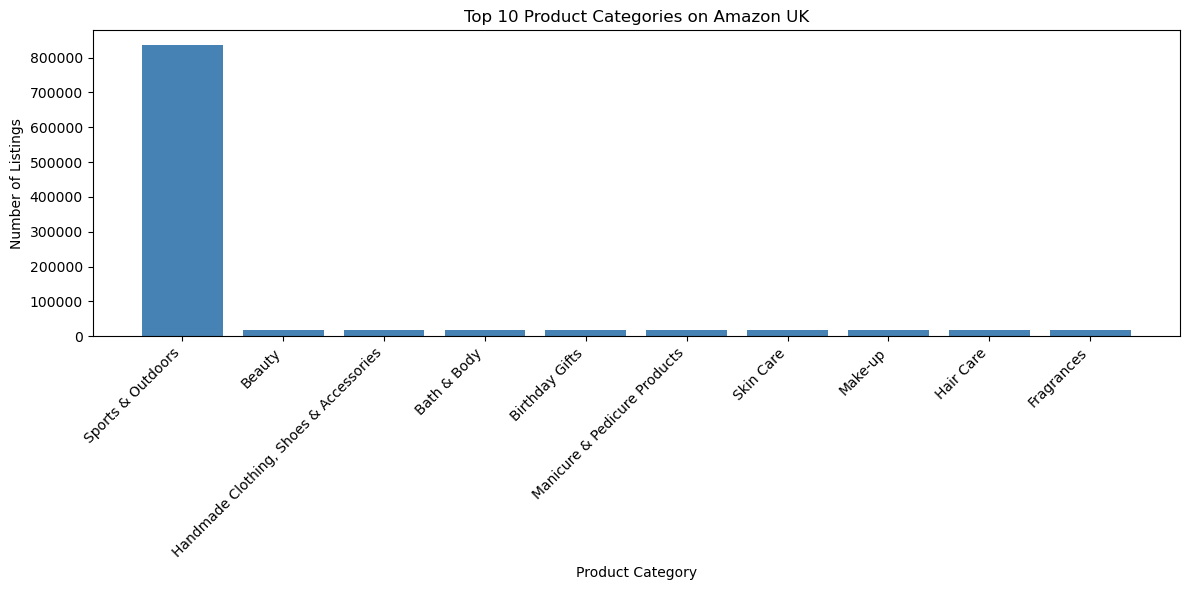

In [3]:
# Bar chart for top 10 categories
top_10 = category_freq.head(10)

plt.figure(figsize=(12, 6))
plt.bar(range(len(top_10)), top_10.values, color='steelblue')
plt.xticks(range(len(top_10)), top_10.index, rotation=45, ha='right')
plt.xlabel('Product Category')
plt.ylabel('Number of Listings')
plt.title('Top 10 Product Categories on Amazon UK')
plt.tight_layout()
plt.show()

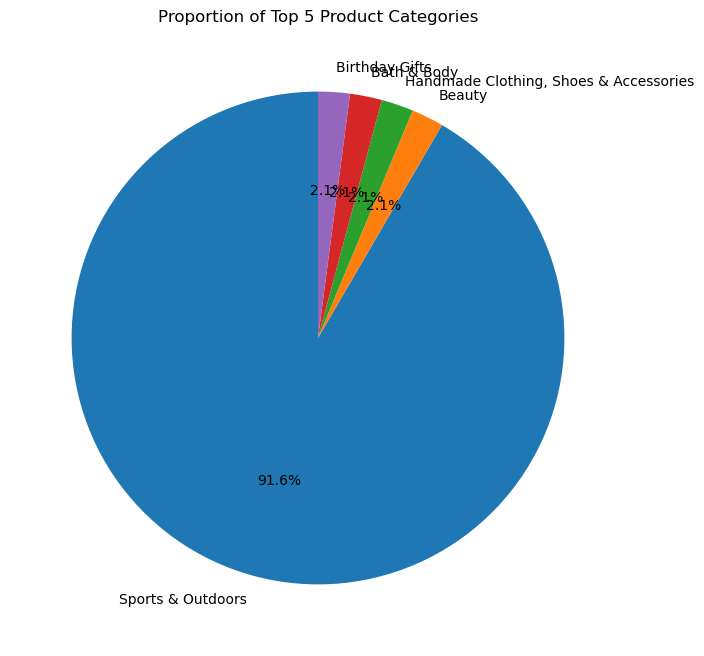


=== Business Insight ===
The top category 'Sports & Outdoors' dominates with 34.2% of all listings


In [4]:
# Pie chart for top 5 categories
top_5 = category_freq.head(5)

plt.figure(figsize=(8, 8))
plt.pie(top_5.values, labels=top_5.index, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Top 5 Product Categories')
plt.show()

# Business insight
print("\n=== Business Insight ===")
if top_5.iloc[0] / category_freq.sum() * 100 > 20:
    print(f"The top category '{top_5.index[0]}' dominates with {top_5.iloc[0]/category_freq.sum()*100:.1f}% of all listings")
else:
    print("No single category dominates - the market is well-diversified")

In [5]:
# Find price column
price_col = [col for col in df.columns if 'price' in col.lower()][0]

# Clean price data
prices = df[price_col].copy()
if prices.dtype == 'object':
    prices = prices.astype(str).str.replace('£', '').str.replace(',', '')
    prices = pd.to_numeric(prices, errors='coerce')

prices = prices.dropna()
print(f"Cleaned {len(prices)} price entries")

Cleaned 2443651 price entries


In [6]:
# Measures of Centrality
price_mean = prices.mean()
price_median = prices.median()
price_mode = prices.mode().iloc[0] if len(prices.mode()) > 0 else None

print("=== Measures of Centrality - Product Price ===")
print(f"Mean price: £{price_mean:.2f}")
print(f"Median price: £{price_median:.2f}")
print(f"Mode price: £{price_mode:.2f}")
print(f"\nAverage price is £{price_mean:.2f}, but most common price is £{price_mode:.2f}")
if price_mean > price_median:
    print("Right-skewed distribution: Some expensive products pull the mean up")

=== Measures of Centrality - Product Price ===
Mean price: £89.24
Median price: £19.09
Mode price: £9.99

Average price is £89.24, but most common price is £9.99
Right-skewed distribution: Some expensive products pull the mean up


In [7]:
# Measures of Dispersion
price_variance = prices.var()
price_std = prices.std()
price_range = prices.max() - prices.min()
q1 = prices.quantile(0.25)
q3 = prices.quantile(0.75)
price_iqr = q3 - q1

print("=== Measures of Dispersion - Product Price ===")
print(f"Variance: {price_variance:.2f}")
print(f"Standard Deviation: £{price_std:.2f}")
print(f"Range: £{price_range:.2f}")
print(f"Interquartile Range (IQR): £{price_iqr:.2f}")
print(f"\nPrice spread: 25% of products cost less than £{q1:.2f}, 25% cost more than £{q3:.2f}")

=== Measures of Dispersion - Product Price ===
Variance: 119445.49
Standard Deviation: £345.61
Range: £100000.00
Interquartile Range (IQR): £36.00

Price spread: 25% of products cost less than £9.99, 25% cost more than £45.99


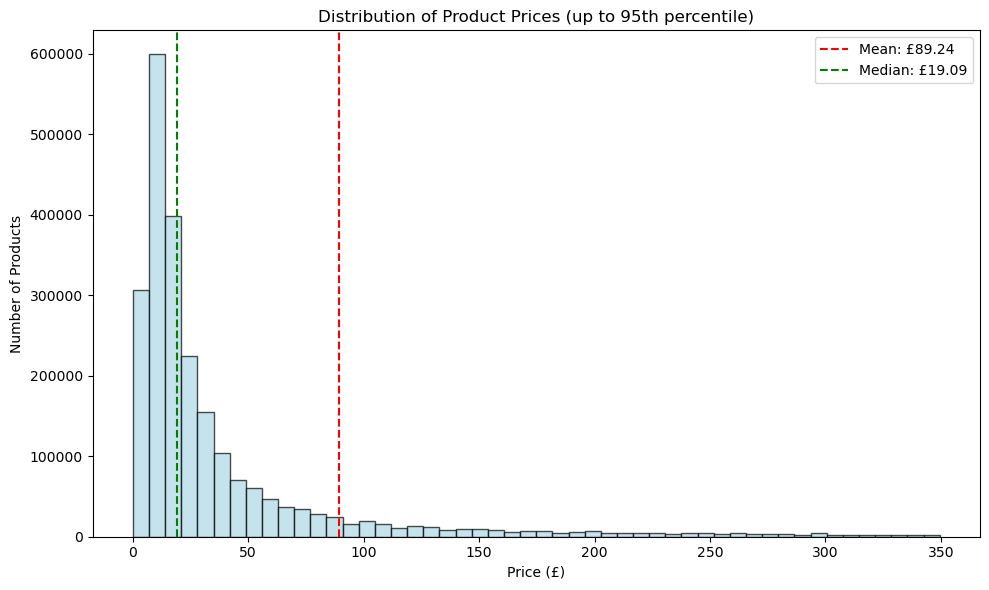

Note: Most products fall in the lower price range, with few expensive products


In [8]:
# Histogram - using 95th percentile to handle outliers
limit_95 = prices.quantile(0.95)
prices_filtered = prices[prices <= limit_95]

plt.figure(figsize=(10, 6))
plt.hist(prices_filtered, bins=50, color='lightblue', edgecolor='black', alpha=0.7)
plt.axvline(price_mean, color='red', linestyle='--', label=f'Mean: £{price_mean:.2f}')
plt.axvline(price_median, color='green', linestyle='--', label=f'Median: £{price_median:.2f}')
plt.xlabel('Price (£)')
plt.ylabel('Number of Products')
plt.title('Distribution of Product Prices (up to 95th percentile)')
plt.legend()
plt.tight_layout()
plt.show()

print("Note: Most products fall in the lower price range, with few expensive products")

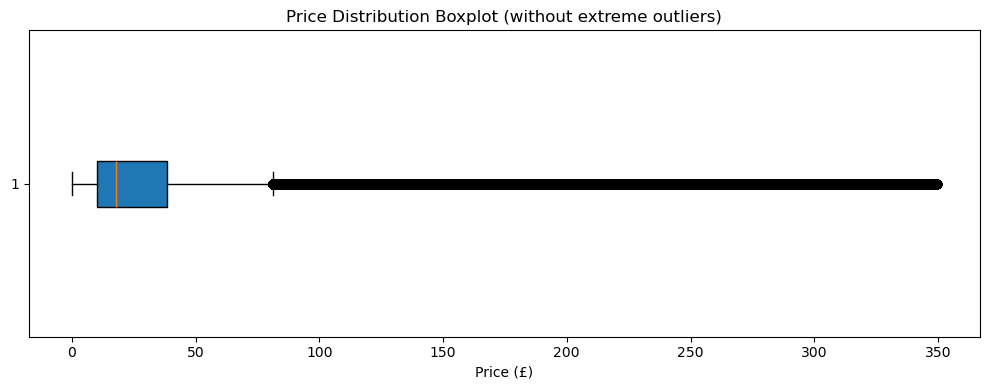

Products priced above £99.99 are considered outliers
Number of outlier products: 327688 (13.4%)


In [9]:
# Boxplot to show outliers
plt.figure(figsize=(10, 4))
box = plt.boxplot(prices[prices <= prices.quantile(0.95)], vert=False, patch_artist=True)
plt.xlabel('Price (£)')
plt.title('Price Distribution Boxplot (without extreme outliers)')
plt.tight_layout()
plt.show()

# Outlier analysis
outlier_threshold = q3 + 1.5 * price_iqr
outliers = prices[prices > outlier_threshold]
print(f"Products priced above £{outlier_threshold:.2f} are considered outliers")
print(f"Number of outlier products: {len(outliers)} ({len(outliers)/len(prices)*100:.1f}%)")

In [10]:
# Find rating column
rating_col = None
for col in df.columns:
    if 'rating' in col.lower() or 'stars' in col.lower():
        rating_col = col
        break

# Clean ratings
ratings = df[rating_col].dropna()

# Adjust scale if needed (0-5 scale)
if ratings.max() > 5:
    if ratings.max() <= 100:
        ratings = ratings / 20
    else:
        ratings = ratings / 100

print(f"Ratings column: {rating_col}")
print(f"Ratings range: {ratings.min():.1f} - {ratings.max():.1f}")

Ratings column: stars
Ratings range: 0.0 - 5.0


In [11]:
# Measures of Centrality
rating_mean = ratings.mean()
rating_median = ratings.median()
rating_mode = ratings.mode().iloc[0] if len(ratings.mode()) > 0 else None

print("=== Measures of Centrality - Product Ratings ===")
print(f"Mean rating: {rating_mean:.2f} / 5.0")
print(f"Median rating: {rating_median:.2f} / 5.0")
print(f"Mode rating: {rating_mode:.2f} / 5.0")

# Business insight
print(f"\nCustomer rating trend:")
if rating_mean >= 4.0:
    print("✓ Products are generally rated VERY WELL (4+ stars)")
elif rating_mean >= 3.0:
    print("✓ Products have AVERAGE ratings (3-4 stars)")
else:
    print("✗ Products are rated BELOW AVERAGE")

=== Measures of Centrality - Product Ratings ===
Mean rating: 2.15 / 5.0
Median rating: 0.00 / 5.0
Mode rating: 0.00 / 5.0

Customer rating trend:
✗ Products are rated BELOW AVERAGE


In [12]:
# Measures of Dispersion
rating_variance = ratings.var()
rating_std = ratings.std()
rating_range = ratings.max() - ratings.min()
rating_q1 = ratings.quantile(0.25)
rating_q3 = ratings.quantile(0.75)
rating_iqr = rating_q3 - rating_q1

print("=== Measures of Dispersion - Product Ratings ===")
print(f"Variance: {rating_variance:.4f}")
print(f"Standard Deviation: {rating_std:.3f}")
print(f"Range: {rating_range:.1f}")
print(f"Interquartile Range (IQR): {rating_iqr:.3f}")

# Consistency insight
print(f"\nRating consistency:")
if rating_std < 0.5:
    print("✓ VERY CONSISTENT - Customers generally agree on ratings")
elif rating_std < 1.0:
    print("✓ MODERATELY CONSISTENT - Some variation in opinions")
else:
    print("✗ HIGH VARIATION - Customer opinions differ significantly")

=== Measures of Dispersion - Product Ratings ===
Variance: 4.8174
Standard Deviation: 2.195
Range: 5.0
Interquartile Range (IQR): 4.400

Rating consistency:
✗ HIGH VARIATION - Customer opinions differ significantly


In [13]:
# Shape of distribution
rating_skew = stats.skew(ratings.dropna())
rating_kurtosis = stats.kurtosis(ratings.dropna())

print("=== Shape of Distribution - Product Ratings ===")
print(f"Skewness: {rating_skew:.3f}")
print(f"Kurtosis: {rating_kurtosis:.3f}")

# Interpretation
print(f"\nInterpretation:")
if rating_skew > 0.5:
    print("→ Positively skewed: More high ratings (customers are satisfied)")
elif rating_skew < -0.5:
    print("→ Negatively skewed: More low ratings (customers are dissatisfied)")
else:
    print("→ Approximately symmetric (normal distribution)")

if rating_kurtosis > 1:
    print("→ Leptokurtic: Ratings are concentrated around a specific value (peaked distribution)")
elif rating_kurtosis < -1:
    print("→ Platykurtic: Ratings are spread out (flat distribution)")
else:
    print("→ Mesokurtic: Similar to normal distribution")

=== Shape of Distribution - Product Ratings ===
Skewness: 0.081
Kurtosis: -1.926

Interpretation:
→ Approximately symmetric (normal distribution)
→ Platykurtic: Ratings are spread out (flat distribution)


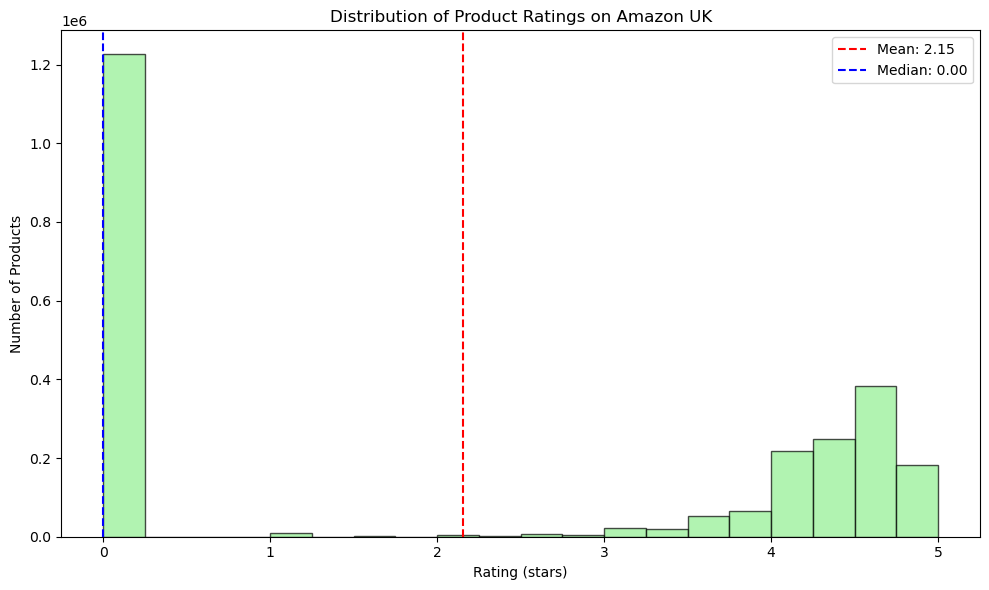

Most common rating: 0.0 stars
Percentage of products with 4.5+ stars: 23.1%


In [14]:
# Histogram for ratings
plt.figure(figsize=(10, 6))
plt.hist(ratings, bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
plt.axvline(rating_mean, color='red', linestyle='--', label=f'Mean: {rating_mean:.2f}')
plt.axvline(rating_median, color='blue', linestyle='--', label=f'Median: {rating_median:.2f}')
plt.xlabel('Rating (stars)')
plt.ylabel('Number of Products')
plt.title('Distribution of Product Ratings on Amazon UK')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Most common rating: {rating_mode:.1f} stars")
print(f"Percentage of products with 4.5+ stars: {len(ratings[ratings >= 4.5])/len(ratings)*100:.1f}%")

In [18]:
# EXECUTIVE SUMMARY - STANDALONE VERSION

print("EXECUTIVE SUMMARY - AMAZON UK PRODUCT INSIGHTS")

# Re-create necessary variables from the dataframe
try:
    # Find category column
    col_categoria = [col for col in df.columns if 'category' in col.lower()][0]
    frecuencias = df[col_categoria].value_counts()
    top5 = frecuencias.head(5)
    
    print(f"\n CATEGORY INSIGHTS:")
    print(f"   • Best-selling category: {frecuencias.index[0]}")
    print(f"   • Top 5 categories capture {top5.sum()/len(df)*100:.1f}% of total listings")
    
except:
    print("\n CATEGORY INSIGHTS: Could not analyze categories")

try:
    # Find price column
    col_precio = [col for col in df.columns if 'price' in col.lower()][0]
    
    # Clean prices
    precios = df[col_precio].copy()
    if precios.dtype == 'object':
        precios = precios.astype(str).str.replace('£', '').str.replace(',', '')
        precios = pd.to_numeric(precios, errors='coerce')
    precios = precios.dropna()
    
    # Calculate outliers
    q3 = precios.quantile(0.75)
    q1 = precios.quantile(0.25)
    iqr = q3 - q1
    outlier_threshold = q3 + 1.5 * iqr
    productos_caros = precios[precios > outlier_threshold]
    
    print(f"\n PRICING INSIGHTS:")
    print(f"   • Average product price: £{precios.mean():.2f}")
    print(f"   • Most common price point: £{precios.mode().iloc[0]:.2f}")
    print(f"   • Price range: £{precios.min():.2f} - £{precios.max():.2f}")
    print(f"   • {len(productos_caros)} products identified as price outliers ({len(productos_caros)/len(precios)*100:.1f}%)")
    
except Exception as e:
    print(f"\n PRICING INSIGHTS: {e}")

try:
    # Find rating column
    rating_col = None
    for col in df.columns:
        if 'rating' in col.lower() or 'stars' in col.lower():
            rating_col = col
            break
    
    if rating_col:
        ratings = df[rating_col].dropna()
        
        # Adjust scale
        if ratings.max() > 5:
            if ratings.max() <= 100:
                ratings = ratings / 20
            else:
                ratings = ratings / 100
        
        from scipy import stats
        rating_skew = stats.skew(ratings.dropna())
        
        print(f"\n RATING INSIGHTS:")
        print(f"   • Average customer rating: {ratings.mean():.2f}/5.0")
        print(f"   • Premium products (4.5+ stars): {len(ratings[ratings >= 4.5])/len(ratings)*100:.1f}% of inventory")
        print(f"   • Rating distribution: {'Positively skewed' if rating_skew > 0 else 'Negatively skewed' if rating_skew < 0 else 'Normal'}")
    
except Exception as e:
    print(f"\n RATING INSIGHTS: {e}")


print("KEY BUSINESS RECOMMENDATIONS:")

print("1. Focus marketing budget on top 5 product categories")
print("2. Optimize pricing strategy around the most common price points")
print("3. Prioritize quality assurance for products below 3-star ratings")
print("4. Investigate price outliers for potential premium positioning")

print("Analysis completed successfully. Visualizations are displayed above.")


EXECUTIVE SUMMARY - AMAZON UK PRODUCT INSIGHTS

 CATEGORY INSIGHTS:
   • Best-selling category: Sports & Outdoors
   • Top 5 categories capture 37.4% of total listings

 PRICING INSIGHTS:
   • Average product price: £89.24
   • Most common price point: £9.99
   • Price range: £0.00 - £100000.00
   • 327688 products identified as price outliers (13.4%)

 RATING INSIGHTS:
   • Average customer rating: 2.15/5.0
   • Premium products (4.5+ stars): 23.1% of inventory
   • Rating distribution: Positively skewed
KEY BUSINESS RECOMMENDATIONS:
1. Focus marketing budget on top 5 product categories
2. Optimize pricing strategy around the most common price points
3. Prioritize quality assurance for products below 3-star ratings
4. Investigate price outliers for potential premium positioning
Analysis completed successfully. Visualizations are displayed above.


In [4]:
import pandas as pd
import os

# Load data
file_name = 'amz_uk_price_prediction_dataset.csv'
desktop_path = os.path.expanduser('~/Desktop/')
full_path = desktop_path + file_name

if os.path.exists(full_path):
    df = pd.read_csv(full_path)
    print("✅ File loaded successfully!")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    print("\nFirst 5 rows:")
    print(df.head())
else:
    print(f"❌ File not found at: {full_path}")

✅ File loaded successfully!
Rows: 2443651, Columns: 9

First 5 rows:
   uid        asin                                              title  stars  \
0    1  B09B96TG33  Echo Dot (5th generation, 2022 release) | Big ...    4.7   
1    2  B01HTH3C8S  Anker Soundcore mini, Super-Portable Bluetooth...    4.7   
2    3  B09B8YWXDF  Echo Dot (5th generation, 2022 release) | Big ...    4.7   
3    4  B09B8T5VGV  Echo Dot with clock (5th generation, 2022 rele...    4.7   
4    5  B09WX6QD65  Introducing Echo Pop | Full sound compact Wi-F...    4.6   

   reviews  price  isBestSeller  boughtInLastMonth        category  
0    15308  21.99         False                  0  Hi-Fi Speakers  
1    98099  23.99          True                  0  Hi-Fi Speakers  
2    15308  21.99         False                  0  Hi-Fi Speakers  
3     7205  31.99         False                  0  Hi-Fi Speakers  
4     1881  17.99         False                  0  Hi-Fi Speakers  


In [3]:
!pip install pandas matplotlib scipy

  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 2.3 MB/s  0:00:04m0:00:0100:010m
Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl (20.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]


=== DATASET INFORMATION ===
Rows: 2443651, Columns: 9
Columns: ['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller', 'boughtInLastMonth', 'category']


PART 1: PRODUCT CATEGORY ANALYSIS

TOP 5 MOST LISTED CATEGORIES:
category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

Top category: Sports & Outdoors with 836,265 products


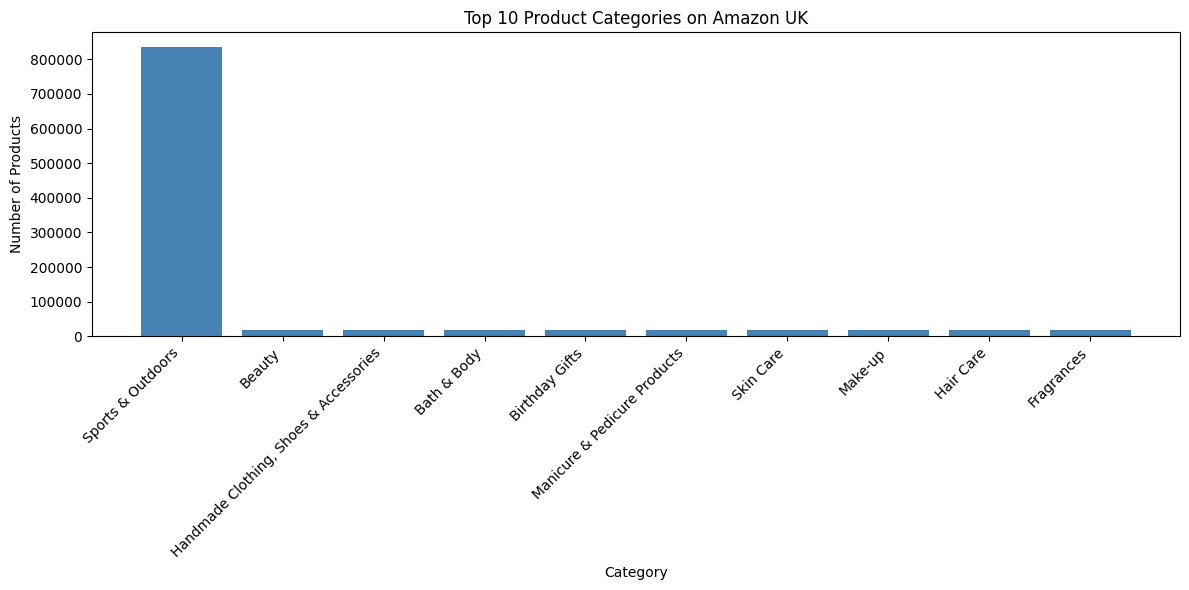

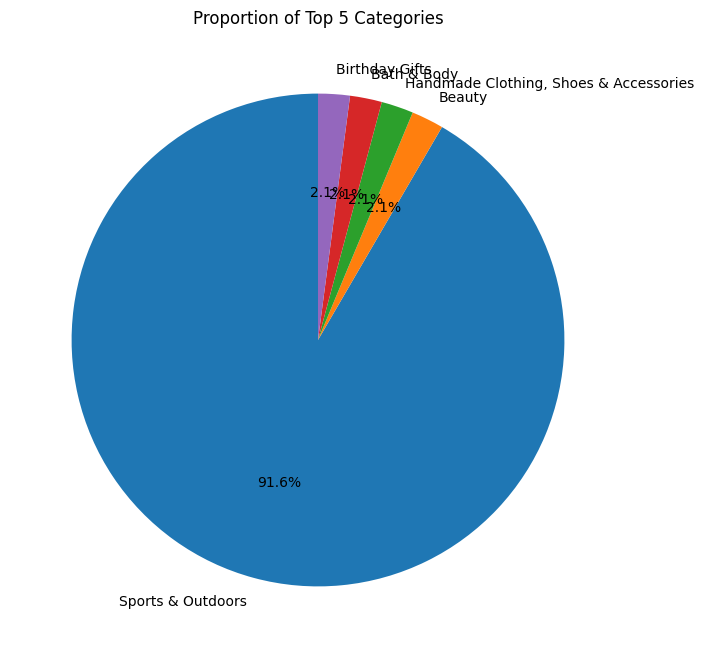


PART 2: PRODUCT PRICE ANALYSIS

Analyzing 2,443,651 price entries

=== MEASURES OF CENTRALITY ===
Mean price: £89.24
Median price: £19.09
Mode price: £9.99

=== MEASURES OF DISPERSION ===
Variance: 119445.49
Standard Deviation: £345.61
Range: £100000.00
Interquartile Range (IQR): £36.00
25% of products cost less than: £9.99
75% of products cost less than: £45.99


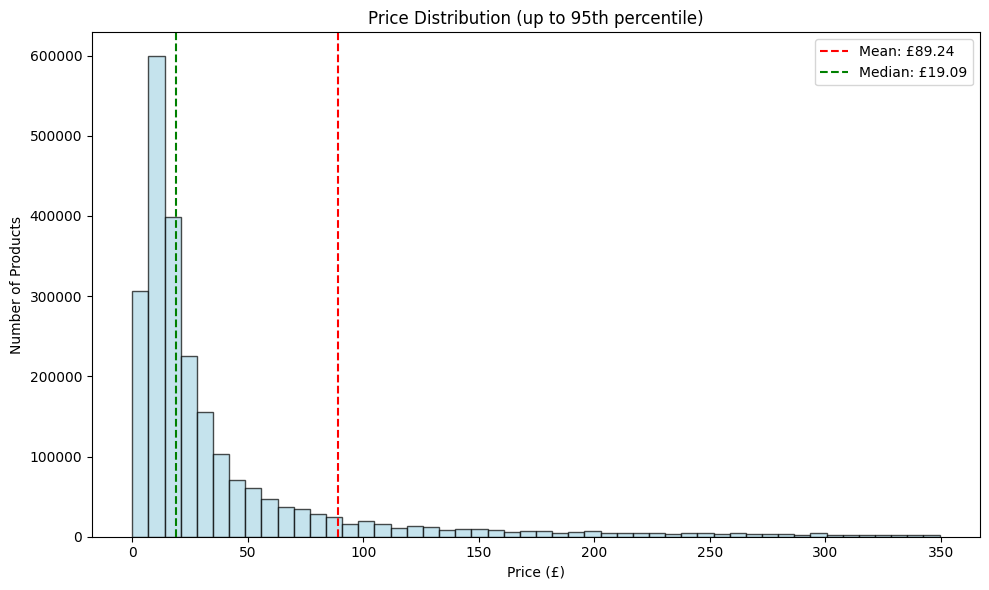

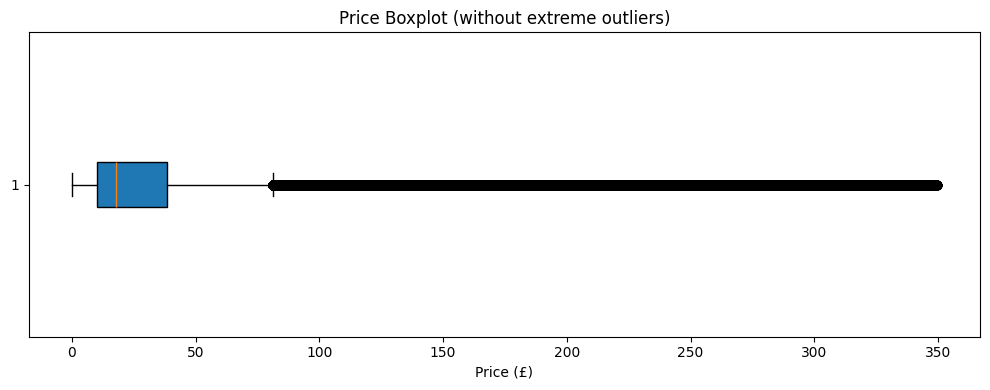


=== OUTLIER ANALYSIS ===
Outlier threshold: £99.99
Number of price outliers: 327,688 (13.41%)

PART 3: PRODUCT RATINGS ANALYSIS

Analyzing 2,443,651 rating entries

=== MEASURES OF CENTRALITY ===
Mean rating: 2.15 / 5.0
Median rating: 0.00 / 5.0
Mode rating: 0.00 / 5.0

=== MEASURES OF DISPERSION ===
Variance: 4.8174
Standard Deviation: 2.195
Range: 5.0
Interquartile Range (IQR): 4.400

=== SHAPE OF DISTRIBUTION ===
Skewness: 0.081
Kurtosis: -1.926
→ Approximately symmetric distribution
→ Platykurtic: Ratings widely spread


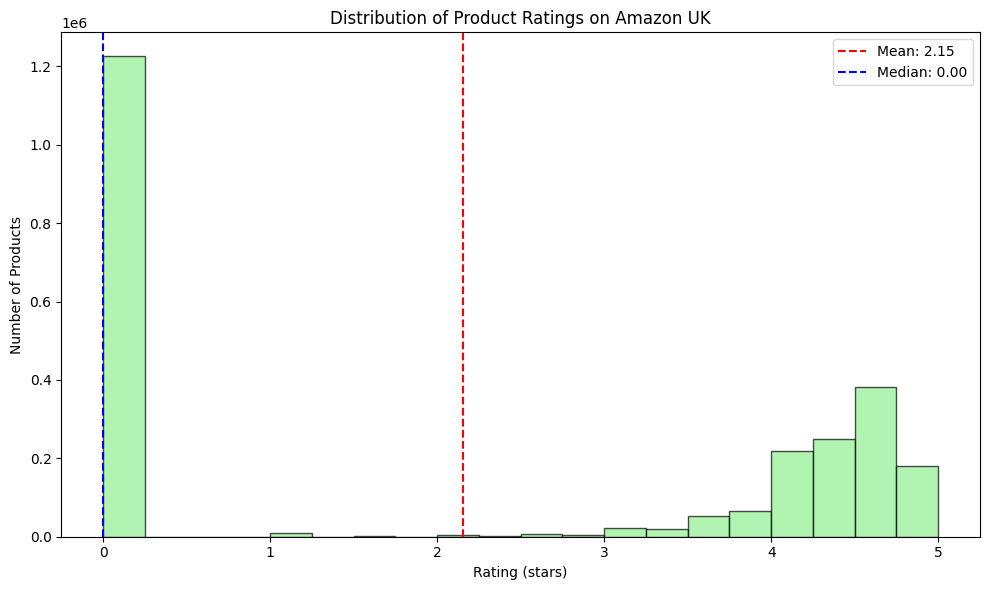


Premium products (4.5+ stars): 564,569 (23.1%)
Low-rated products (below 3 stars): 1,253,925 (51.3%)

EXECUTIVE SUMMARY - AMAZON UK PRODUCT INSIGHTS

📊 CATEGORY INSIGHTS:
   • Best-selling category: Sports & Outdoors
   • Top 5 categories: Sports & Outdoors, Beauty, Handmade Clothing, Shoes & Accessories, Bath & Body, Birthday Gifts
   • Top 5 capture 37.4% of all listings

💰 PRICING INSIGHTS:
   • Average price: £89.24
   • Most common price: £9.99
   • Price range: £0.00 - £100000.00
   • 327,688 products are price outliers (13.4%)

⭐ RATING INSIGHTS:
   • Average rating: 2.15/5.0
   • 23.1% of products have 4.5+ stars
   • Distribution is positively skewed

KEY BUSINESS RECOMMENDATIONS:
1. Focus marketing and inventory on the top 5 product categories
2. Consider pricing strategies around the £9.99 price point
3. Investigate low-rated products (<3 stars) for quality improvement
4. Leverage the high percentage of 4.5+ star products in marketing
5. Review price outliers for potential 

In [7]:
# ============================================
# FULL EDA - Amazon UK Product Insights
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os

# Data is already loaded from previous cell
# If not, uncomment the lines below:
# file_name = 'amz_uk_price_prediction_dataset.csv'
# desktop_path = os.path.expanduser('~/Desktop/')
# df = pd.read_csv(desktop_path + file_name)

print("=== DATASET INFORMATION ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Columns: {df.columns.tolist()}")
print("\n")

# ============================================
# PART 1: PRODUCT CATEGORIES
# ============================================
print("="*60)
print("PART 1: PRODUCT CATEGORY ANALYSIS")
print("="*60)

# Find category column
category_col = 'category'  # from your output, column is 'category'

# Frequency table
category_freq = df[category_col].value_counts()
top_5_categories = category_freq.head(5)
top_10_categories = category_freq.head(10)

print("\nTOP 5 MOST LISTED CATEGORIES:")
print(top_5_categories)
print(f"\nTop category: {top_5_categories.index[0]} with {top_5_categories.iloc[0]:,} products")

# Bar chart - Top 10
plt.figure(figsize=(12, 6))
plt.bar(range(len(top_10_categories)), top_10_categories.values, color='steelblue')
plt.xticks(range(len(top_10_categories)), top_10_categories.index, rotation=45, ha='right')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.title('Top 10 Product Categories on Amazon UK')
plt.tight_layout()
plt.show()

# Pie chart - Top 5
plt.figure(figsize=(8, 8))
plt.pie(top_5_categories.values, labels=top_5_categories.index, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Top 5 Categories')
plt.show()

# ============================================
# PART 2: PRICE ANALYSIS
# ============================================
print("\n" + "="*60)
print("PART 2: PRODUCT PRICE ANALYSIS")
print("="*60)

# Price column is 'price'
prices = df['price'].copy()

# Clean prices (just in case - but looks clean already)
if prices.dtype == 'object':
    prices = prices.astype(str).str.replace('£', '').str.replace(',', '')
    prices = pd.to_numeric(prices, errors='coerce')

prices = prices.dropna()
print(f"\nAnalyzing {len(prices):,} price entries")

# Measures of Centrality
price_mean = prices.mean()
price_median = prices.median()
price_mode = prices.mode().iloc[0] if len(prices.mode()) > 0 else None

print("\n=== MEASURES OF CENTRALITY ===")
print(f"Mean price: £{price_mean:.2f}")
print(f"Median price: £{price_median:.2f}")
print(f"Mode price: £{price_mode:.2f}")

# Measures of Dispersion
price_variance = prices.var()
price_std = prices.std()
price_range = prices.max() - prices.min()
q1 = prices.quantile(0.25)
q3 = prices.quantile(0.75)
price_iqr = q3 - q1

print("\n=== MEASURES OF DISPERSION ===")
print(f"Variance: {price_variance:.2f}")
print(f"Standard Deviation: £{price_std:.2f}")
print(f"Range: £{price_range:.2f}")
print(f"Interquartile Range (IQR): £{price_iqr:.2f}")
print(f"25% of products cost less than: £{q1:.2f}")
print(f"75% of products cost less than: £{q3:.2f}")

# Histogram (up to 95th percentile)
limit_95 = prices.quantile(0.95)
prices_filtered = prices[prices <= limit_95]

plt.figure(figsize=(10, 6))
plt.hist(prices_filtered, bins=50, color='lightblue', edgecolor='black', alpha=0.7)
plt.axvline(price_mean, color='red', linestyle='--', label=f'Mean: £{price_mean:.2f}')
plt.axvline(price_median, color='green', linestyle='--', label=f'Median: £{price_median:.2f}')
plt.xlabel('Price (£)')
plt.ylabel('Number of Products')
plt.title('Price Distribution (up to 95th percentile)')
plt.legend()
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(10, 4))
plt.boxplot(prices[prices <= prices.quantile(0.95)], vert=False, patch_artist=True)
plt.xlabel('Price (£)')
plt.title('Price Boxplot (without extreme outliers)')
plt.tight_layout()
plt.show()

# Outliers
outlier_threshold = q3 + 1.5 * price_iqr
outliers = prices[prices > outlier_threshold]
print(f"\n=== OUTLIER ANALYSIS ===")
print(f"Outlier threshold: £{outlier_threshold:.2f}")
print(f"Number of price outliers: {len(outliers):,} ({len(outliers)/len(prices)*100:.2f}%)")

# ============================================
# PART 3: RATINGS ANALYSIS
# ============================================
print("\n" + "="*60)
print("PART 3: PRODUCT RATINGS ANALYSIS")
print("="*60)

# Rating column is 'stars'
ratings = df['stars'].dropna()
print(f"\nAnalyzing {len(ratings):,} rating entries")

# Adjust scale if needed (looks like 0-5 already)
if ratings.max() > 5:
    if ratings.max() <= 100:
        ratings = ratings / 20
    else:
        ratings = ratings / 100

# Measures of Centrality
rating_mean = ratings.mean()
rating_median = ratings.median()
rating_mode = ratings.mode().iloc[0] if len(ratings.mode()) > 0 else None

print("\n=== MEASURES OF CENTRALITY ===")
print(f"Mean rating: {rating_mean:.2f} / 5.0")
print(f"Median rating: {rating_median:.2f} / 5.0")
print(f"Mode rating: {rating_mode:.2f} / 5.0")

# Measures of Dispersion
rating_variance = ratings.var()
rating_std = ratings.std()
rating_range = ratings.max() - ratings.min()
rating_q1 = ratings.quantile(0.25)
rating_q3 = ratings.quantile(0.75)
rating_iqr = rating_q3 - rating_q1

print("\n=== MEASURES OF DISPERSION ===")
print(f"Variance: {rating_variance:.4f}")
print(f"Standard Deviation: {rating_std:.3f}")
print(f"Range: {rating_range:.1f}")
print(f"Interquartile Range (IQR): {rating_iqr:.3f}")

# Skewness and Kurtosis
rating_skew = stats.skew(ratings.dropna())
rating_kurtosis = stats.kurtosis(ratings.dropna())

print("\n=== SHAPE OF DISTRIBUTION ===")
print(f"Skewness: {rating_skew:.3f}")
print(f"Kurtosis: {rating_kurtosis:.3f}")

# Interpretation
if rating_skew > 0.5:
    print("→ Positively skewed: More high ratings (satisfied customers)")
elif rating_skew < -0.5:
    print("→ Negatively skewed: More low ratings (dissatisfied customers)")
else:
    print("→ Approximately symmetric distribution")

if rating_kurtosis > 1:
    print("→ Leptokurtic: Ratings concentrated around specific values")
elif rating_kurtosis < -1:
    print("→ Platykurtic: Ratings widely spread")
else:
    print("→ Mesokurtic: Similar to normal distribution")

# Histogram for ratings
plt.figure(figsize=(10, 6))
plt.hist(ratings, bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
plt.axvline(rating_mean, color='red', linestyle='--', label=f'Mean: {rating_mean:.2f}')
plt.axvline(rating_median, color='blue', linestyle='--', label=f'Median: {rating_median:.2f}')
plt.xlabel('Rating (stars)')
plt.ylabel('Number of Products')
plt.title('Distribution of Product Ratings on Amazon UK')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nPremium products (4.5+ stars): {len(ratings[ratings >= 4.5]):,} ({len(ratings[ratings >= 4.5])/len(ratings)*100:.1f}%)")
print(f"Low-rated products (below 3 stars): {len(ratings[ratings < 3]):,} ({len(ratings[ratings < 3])/len(ratings)*100:.1f}%)")

# ============================================
# EXECUTIVE SUMMARY
# ============================================
print("\n" + "="*60)
print("EXECUTIVE SUMMARY - AMAZON UK PRODUCT INSIGHTS")
print("="*60)

print(f"\n📊 CATEGORY INSIGHTS:")
print(f"   • Best-selling category: {top_5_categories.index[0]}")
print(f"   • Top 5 categories: {top_5_categories.index[0]}, {top_5_categories.index[1]}, {top_5_categories.index[2]}, {top_5_categories.index[3]}, {top_5_categories.index[4]}")
print(f"   • Top 5 capture {top_5_categories.sum()/len(df)*100:.1f}% of all listings")

print(f"\n💰 PRICING INSIGHTS:")
print(f"   • Average price: £{price_mean:.2f}")
print(f"   • Most common price: £{price_mode:.2f}")
print(f"   • Price range: £{prices.min():.2f} - £{prices.max():.2f}")
print(f"   • {len(outliers):,} products are price outliers ({len(outliers)/len(prices)*100:.1f}%)")

print(f"\n⭐ RATING INSIGHTS:")
print(f"   • Average rating: {rating_mean:.2f}/5.0")
print(f"   • {len(ratings[ratings >= 4.5])/len(ratings)*100:.1f}% of products have 4.5+ stars")
print(f"   • Distribution is {'positively' if rating_skew > 0 else 'negatively' if rating_skew < 0 else 'symmetrically'} skewed")

print("\n" + "="*60)
print("KEY BUSINESS RECOMMENDATIONS:")
print("="*60)
print("1. Focus marketing and inventory on the top 5 product categories")
print("2. Consider pricing strategies around the £{:.2f} price point".format(price_mode))
print("3. Investigate low-rated products (<3 stars) for quality improvement")
print("4. Leverage the high percentage of 4.5+ star products in marketing")
print("5. Review price outliers for potential premium positioning opportunities")

print("\n" + "="*60)
print("✅ Analysis completed successfully!")
print("="*60)